# C4. 데이터 누수 — 자기참조 평가셋

| | |
|---|---|
| **트랙** | C 평가 |
| **선수 토픽** | C1 |
| **프로젝트 앵커** | 52문항 병합 평가셋 · 자기참조 46건 · natural query 자연화 |
| **작성일** | 2026-07-29 |
| **최종 검증** | 2026-07-29 |
| **상태** | 검증완료 |

## 한 줄 요약
> 평가 질의를 정답 청크에서 뽑아 쓰면 검색기는 의미가 아니라 문자열을 맞히게 되고, 그때의
> hit@k는 검색 성능이 아니라 질의와 정답의 어휘 겹침을 잰 값이 된다.

## 0. 준비

필요 패키지는 `numpy`, `matplotlib` 뿐이다. 누수는 평가셋의 **생성 방식**에서 오는 문제라
실제 코퍼스 없이도 재현된다. §4에서 개념·동의어 구조를 가진 합성 코퍼스를 만들고, 질의를
정답 문서에서 파생시킬 때와 다른 표현으로 바꿔 물었을 때를 나란히 잰다.

In [1]:
# ── 표준 셋업 ────────────────────────────────────────────
from __future__ import annotations

import pathlib
import random

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ASSETS = pathlib.Path("../assets")
OUT = pathlib.Path("./out"); OUT.mkdir(exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

# 팔레트 (FUNDAMENTAL 시리즈 공용)
C_MAIN, C_SUB, C_GRAY = "#ee4c2c", "#0d9488", "#94a3b8"

_installed = {f.name for f in fm.fontManager.ttflist}
for _f in ("AppleGothic", "Malgun Gothic", "NanumGothic"):
    if _f in _installed:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.figsize"] = (7, 4)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

print(f"seed={SEED} · font={mpl.rcParams['font.family'][0]}")

seed=42 · font=sans-serif


## 1. 개념

### 누수는 정답을 알려주는 게 아니라 지름길을 열어주는 것이다

평가에서의 누수는 시스템이 **정상 입력 경로 밖에서** 정답에 대한 정보를 받는 상황을 말한다.
IR 평가에서 가장 흔한 형태는 질의를 정답 문서에서 만들어내는 것이다. 문서를 읽고 "이 문서를
찾게 할 질문"을 쓰다 보면 그 문서의 표현이 질의에 그대로 실린다.

> **정의**  질의 $q$가 gold 청크 $d^{*}$의 텍스트에서 파생됐다면, $q$와 $d^{*}$의 어휘 겹침은
> 다른 문서와의 겹침보다 구조적으로 크다. 이때 관측되는 점수는
> $$\text{관측 hit@}k = \text{검색 능력} + \text{파생에서 온 어휘 겹침 이득}$$
> 이며, 두 항은 그 평가셋 안에서 분리되지 않는다.

정답을 직접 알려주는 게 아니라는 점이 중요하다. 시스템은 여전히 검색을 하지만, 훨씬 쉬운
문제를 푼다. 그래서 결과가 그럴듯해 보이고, 그 그럴듯함이 문제를 오래 살아남게 한다.

### sparse가 dense보다 크게 부풀려진다

BM25는 어휘 일치를 직접 센다. 질의 토큰이 정답 문서에서 그대로 잘려 나왔다면 그 토큰의
$\mathrm{tf}$는 정의상 0이 아니고, 그 토큰이 희귀할수록 $\mathrm{idf}$가 커져 정답 문서만
크게 튄다. 파생 질의는 정답 문서의 **희귀 토큰을 물려받는다**는 점에서 BM25에게 사실상
정답 지문을 건네는 것과 같다.

dense는 의미 공간에서 재므로 표현이 바뀌어도 어느 정도 버틴다. 같은 누수라도 두 검색기가
받는 이득의 크기가 다르고, 이 비대칭이 하이브리드 가중치 판단까지 오염시킨다.

### 자연어화는 치료가 아니라 측정이다

질의를 사용자가 실제로 쓸 법한 표현으로 바꾸면 정답 문서에서 물려받은 어휘가 끊긴다. 남는 건
의미 관계뿐이다. 그래서 자연어화 전후의 **하락폭 자체가 누수 크기의 추정치**가 된다.

> **함정**  자연어화 후 점수가 떨어졌다고 시스템이 나빠진 게 아니다. 원래 그 정도였고 그 전
> 숫자가 틀렸던 것이다. 이 하락을 "성능 저하"로 리포트하면 결론의 방향이 정반대가 된다.

### 누수가 들어오는 세 경로

| 경로 | 전형적인 모습 | 증상 |
|---|---|---|
| 질의 파생 | gold 청크의 문장을 잘라 질의로 사용 | sparse 급등, 자연어화 시 붕괴 |
| 라벨 편의 | 현재 검색기의 top-1을 gold로 승인 | 그 검색기 우위가 고정, 대안 비교 불가 |
| 튜닝 중복 | 같은 셋으로 파라미터를 스윕하고 그 값을 보고 | 스윕 폭만큼 낙관 편향 |

두 번째와 세 번째는 자연어화로 잡히지 않는다. 라벨을 어떻게 만들었는지(C5)와 셋을 몇 번
들여다봤는지(C3)가 따로 필요한 이유다.

## 2. 최소 구현

누수 진단의 최소 도구는 질의와 정답 문서의 **어휘 겹침 비율** 하나다. 질의 토큰 중 몇 %가
정답 문서 안에 그대로 있는지를 세면 된다. 아래 세 질의는 같은 정답 문서에 대해 각각 원문
발췌·사용자 표현·무관 질의이며, 겹침만으로 셋이 갈린다.

실제로는 공백이 아니라 형태소 단위로 잘라야 한다(A3). 여기서는 진단 원리만 본다.

In [2]:
GOLD_DOC = "착오송금 반환지원 제도는 잘못 보낸 돈을 예금보험공사가 대신 회수해 돌려주는 절차다"

QUERIES = {
    "파생(원문 발췌)": "착오송금 반환지원 제도는 잘못 보낸 돈을",
    "자연어(사용자)": "잘못 송금한 돈 돌려받으려면 어디에 신청하나요",
    "무관": "예금자보호 한도는 얼마인가요",
}
LEAK_THRESHOLD = 0.7          # 이 이상이면 파생 의심 — 값 자체는 C5에서 조정 대상


def overlap_ratio(query: str, doc: str) -> float:
    """질의 토큰 중 문서에 그대로 등장하는 비율. 1.0에 가까울수록 파생 의심."""
    q, d = set(query.split()), set(doc.split())
    return len(q & d) / len(q)


print(f"{'query':<18}{'overlap':>9}{'flag':>8}")
print("-" * 35)
for label, q in QUERIES.items():
    ratio = overlap_ratio(q, GOLD_DOC)
    flag = "누수의심" if ratio >= LEAK_THRESHOLD else "-"
    print(f"{label:<18}{ratio:>9.4f}{flag:>8}")

query               overlap    flag
-----------------------------------
파생(원문 발췌)            1.0000    누수의심
자연어(사용자)             0.1667       -
무관                   0.0000       -


## 3. 프로젝트 앵커

52문항 병합 평가셋에서 자기참조 문항이 46건이다. 질의를 정답 청크에서 파생시켜 만든 문항이
셋의 대부분을 차지한다는 뜻이고, 그 상태에서 나온 점수는 §1의 분해식에서 두 번째 항이 크게
섞인 값이다. 비율 자체가 주는 충격은 §4-5에서 숫자로 확인한다.

> **프로젝트**  자연어화 후 BM25 단독은 0.90에서 0.73으로 무너진 반면, 하이브리드는 원본
> 0.853에서 자연어 0.753으로 −0.10에 그쳤다(52문항 병합셋, A1 §4-3 기록). 어느 쪽도
> 좋아진 게 아니라, BM25 쪽 점수가 애초에 더 크게 부풀어 있었다는 뜻이다.

> **함정**  같은 자기참조 건에 대해 원본측 수치가 다른 기록에서는 0.923으로 남아 있다
> (자기참조 46건 기준으로 추정되나 모드·분모 미확인). 0.853은 52문항 전체, 0.923은 부분집합일
> 가능성이 높지만 확정된 조건이 붙어 있지 않다. **조건 없는 숫자는 인용할 수 없다**는 규약이
> 정확히 이런 상황을 막으려는 것이며, 이 확인은 C5로 넘긴다.

하이브리드가 덜 떨어졌다는 사실은 dense가 실제로 의미를 잡고 있었다는 증거이지, 하이브리드가
누수에서 자유롭다는 증거가 아니다. §4-4에서 자연어화를 더 밀어붙이면 하이브리드도 무너지는
구간이 나온다.

## 4. 숫자 검증

실제 코퍼스 대신 **개념과 동의어 구조**를 가진 합성 코퍼스를 만든다. 문서는 개념 집합으로
정의되고 각 개념은 동의어 중 하나로 표면화된다. 이렇게 하면 "의미는 같고 표현만 다른" 질의를
정확히 통제된 방식으로 만들 수 있고, 누수의 크기를 눈금 있는 값으로 잴 수 있다.



### 4-1. 합성 코퍼스

문서 400개, 개념 300개, 개념당 동의어 4개다. 각 문서는 토픽 공유 개념 8개와 고유 개념 4개를
갖는다. 동의어 임베딩은 개념 벡터에 잡음을 얹어 만들므로, **표기가 달라도 의미는 가깝다**는
성질이 설계에 들어가 있다.

In [3]:
N_CONCEPT, N_SYN, DIM = 300, 4, 64
N_TOPIC, PER_TOPIC = 8, 50
TOPIC_C, DOC_C, REPEAT, QLEN = 8, 4, 5, 4
N_DOC, VOCAB = N_TOPIC * PER_TOPIC, N_CONCEPT * N_SYN

rng = np.random.default_rng(SEED)


def l2(v: np.ndarray) -> np.ndarray:
    """마지막 축 기준 L2 정규화. 정규화 후 내적이 곧 코사인이다(A1)."""
    return v / np.maximum(np.linalg.norm(v, axis=-1, keepdims=True), 1e-12)


# 동의어는 같은 개념 벡터에서 갈라져 나온다 — 표기가 달라도 의미는 가깝다
concept_vec = rng.normal(size=(N_CONCEPT, DIM))
E = l2(np.repeat(concept_vec, N_SYN, axis=0) + 0.35 * rng.normal(size=(VOCAB, DIM)))

topic_concepts = [rng.choice(N_CONCEPT, TOPIC_C, replace=False) for _ in range(N_TOPIC)]
doc_topic = np.repeat(np.arange(N_TOPIC), PER_TOPIC)

doc_concepts, doc_syn, docs = [], [], []
for t in doc_topic:
    cs = np.concatenate([topic_concepts[t], rng.choice(N_CONCEPT, DOC_C, replace=False)])
    sy = rng.integers(0, N_SYN, size=len(cs))
    doc_concepts.append(cs); doc_syn.append(sy)
    docs.append(np.repeat(cs * N_SYN + sy, REPEAT))      # 토큰 id = 개념 * 동의어수 + 동의어

print(f"문서 {N_DOC}개 · 어휘 {VOCAB}개 · 문서당 토큰 {len(docs[0])}개")
print(f"0번 문서 개념 {len(doc_concepts[0])}개 중 앞 5개: {doc_concepts[0][:5]}")

문서 400개 · 어휘 1200개 · 문서당 토큰 60개
0번 문서 개념 12개 중 앞 5개: [ 85 174 149 241 180]


### 4-2. 검색기 세 개

BM25와 dense를 각각 최소 구현하고 RRF로 합친다. 여기서 중요한
건 검색기의 품질이 아니라, 같은 누수에 대해 **두 검색기가 다르게 반응한다**는 사실이다.

In [4]:
tf = np.zeros((N_DOC, VOCAB))
for i, d in enumerate(docs):
    np.add.at(tf[i], d, 1)

df = (tf > 0).sum(axis=0)
idf = np.log((N_DOC - df + 0.5) / (df + 0.5) + 1)
dl = tf.sum(axis=1); avgdl = dl.mean()
doc_vec = l2(np.array([E[d].mean(axis=0) for d in docs]))


def bm25(q: np.ndarray, k1: float = 1.5, b: float = 0.75) -> np.ndarray:
    """질의 토큰에 대한 BM25 점수 벡터. 어휘가 겹치지 않으면 0이다."""
    qt = np.unique(q)
    sat = (tf[:, qt] * (k1 + 1)) / (tf[:, qt] + k1 * (1 - b + b * dl[:, None] / avgdl))
    return sat @ idf[qt]


def dense(q: np.ndarray) -> np.ndarray:
    """질의 토큰 임베딩 평균과 문서 벡터의 코사인."""
    return doc_vec @ l2(E[q].mean(axis=0))


def rrf(a: np.ndarray, b_: np.ndarray, k: int = 60) -> np.ndarray:
    """두 점수 벡터를 순위로 바꿔 RRF 융합한다."""
    ra = np.empty(N_DOC); ra[np.argsort(-a)] = np.arange(1, N_DOC + 1)
    rb = np.empty(N_DOC); rb[np.argsort(-b_)] = np.arange(1, N_DOC + 1)
    return 1 / (k + ra) + 1 / (k + rb)


print(f"idf 범위 {idf.min():.3f} ~ {idf.max():.3f} · 평균 문서길이 {avgdl:.1f}")

idf 범위 2.198 ~ 6.687 · 평균 문서길이 60.0


### 4-3. 파생 질의 대 자연어 질의

질의는 정답 문서의 개념 4개를 골라 만든다. `rate`는 그중 몇 %를 **다른 동의어로 갈아끼우는가**
이며, `rate=0.0`이 원문 발췌형 파생 질의, `rate=0.5`가 절반을 사용자 표현으로 바꾼 자연어
질의다. 의미(개념 집합)는 어느 쪽이든 동일하다는 점이 핵심이다.

In [5]:
def make_query(g: int, rate: float, rng_q) -> np.ndarray:
    """문서 g의 개념 일부로 질의를 만든다. rate 비율만큼 동의어를 갈아끼운다."""
    pos = rng_q.choice(len(doc_concepts[g]), QLEN, replace=False)
    cs, sy = doc_concepts[g][pos], doc_syn[g][pos]
    flip = rng_q.random(QLEN) < rate
    sy = np.where(flip, (sy + rng_q.integers(1, N_SYN, QLEN)) % N_SYN, sy)
    return cs * N_SYN + sy


def evaluate(rate: float) -> dict[str, float]:
    """자연어화 강도 rate에서 세 검색기의 hit@3와 평균 어휘 겹침을 잰다."""
    rng_q = np.random.default_rng(SEED + 1)        # rate마다 같은 질의를 재현한다
    hits = {"bm25": 0, "dense": 0, "hybrid": 0}
    overlap = []
    for g in range(N_DOC):
        q = make_query(g, rate, rng_q)
        overlap.append(np.mean([t in set(docs[g]) for t in q]))
        bs, ds = bm25(q), dense(q)
        for name, sc in (("bm25", bs), ("dense", ds), ("hybrid", rrf(bs, ds))):
            hits[name] += int(g in np.argsort(-sc)[:3])
    out = {k: v / N_DOC for k, v in hits.items()}
    out["overlap"] = float(np.mean(overlap))
    return out


derived, natural = evaluate(0.0), evaluate(0.5)

print(f"{'':<10}{'overlap':>9}{'bm25':>9}{'dense':>9}{'hybrid':>9}")
print("-" * 46)
for label, r in (("파생", derived), ("자연어", natural)):
    print(f"{label:<10}{r['overlap']:>9.4f}{r['bm25']:>9.4f}"
          f"{r['dense']:>9.4f}{r['hybrid']:>9.4f}")
print(f"{'하락폭':<10}{'':>9}" + "".join(
    f"{natural[k] - derived[k]:>9.4f}" for k in ("bm25", "dense", "hybrid")))

            overlap     bm25    dense   hybrid
----------------------------------------------
파생           1.0000   1.0000   0.7725   0.9225
자연어          0.4844   0.5200   0.6550   0.6850
하락폭                  -0.4800  -0.1175  -0.2375


파생 질의에서 BM25는 만점을 받는다. 어휘가 100% 겹치는 상태에서 희귀 토큰의 $\mathrm{idf}$가
정답 문서 하나만 밀어 올리므로, 이건 검색이라기보다 문자열 조회에 가깝다. 같은 질의를 동의어로
절반만 바꾸자 BM25는 크게 무너지고 dense는 거의 버틴다. **의미는 한 글자도 안 바뀌었는데**
점수가 이만큼 움직였다면, 움직인 만큼이 누수였다.

더 결정적인 건 **검색기의 순위가 뒤집힌다**는 점이다. 파생 질의에서는 BM25가 셋 중 1위지만
자연어 질의에서는 꼴찌가 된다. 이 셋 위에서 "어느 검색기가 좋은가"를 물으면 답이 반대로 나온다.

하이브리드의 하락폭이 BM25 단독보다 작다는 것도 §3에서 인용한 프로젝트 실측과 같은 방향이다.
합성 코퍼스의 절대값은 실제 파이프라인과 비교할 대상이 아니지만, **어느 검색기가 얼마나 크게
부풀려지는가**의 순서는 재현된다.



### 4-4. 자연어화를 계속 밀면 어떻게 되는가

`rate`를 0에서 1까지 옮기며 세 검색기를 함께 본다. 오른쪽 끝은 정답 문서의 표현을 하나도
쓰지 않은 극단이다.

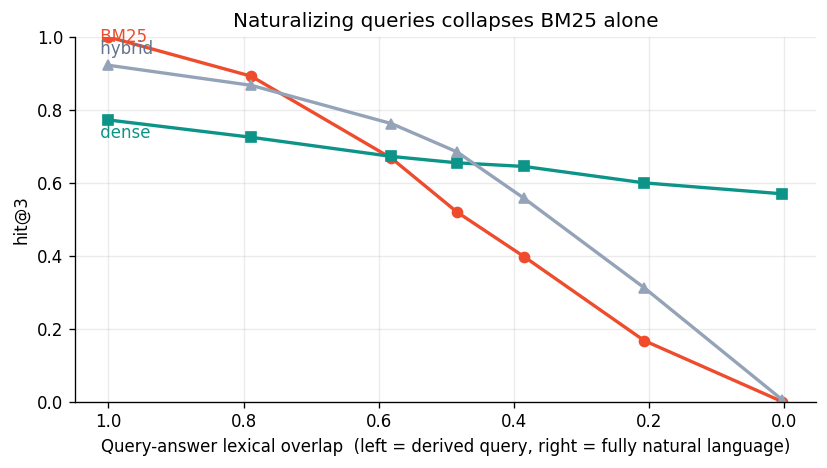

In [8]:
RATES = np.array([0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0])
sweep = [evaluate(r) for r in RATES]
xs = [s["overlap"] for s in sweep]

fig, ax = plt.subplots()
for key, color, marker in (("bm25", C_MAIN, "o"), ("dense", C_SUB, "s"),
                           ("hybrid", C_GRAY, "^")):
    ax.plot(xs, [s[key] for s in sweep], marker + "-", color=color, lw=2.0)

ax.text(xs[0] + 0.02, sweep[0]["bm25"], " BM25", color=C_MAIN, va="center", fontsize=10)
ax.text(xs[0] + 0.02, sweep[0]["dense"] - 0.05, " dense", color=C_SUB, fontsize=10)
ax.text(xs[0] + 0.02, sweep[0]["hybrid"] + 0.03, " hybrid", color="#64748b", fontsize=10)

ax.invert_xaxis()                       # 왼쪽이 누수 상태, 오른쪽으로 갈수록 자연어
ax.set_xlabel("Query-answer lexical overlap  (left = derived query, right = fully natural language)")
ax.set_ylabel("hit@3")
ax.set_ylim(0, 1)
ax.set_title("Naturalizing queries collapses BM25 alone")
plt.tight_layout()
plt.show()

BM25 곡선만 대각선으로 무너지고 dense는 완만하게 내려온다. 어휘 겹침이 사라진 오른쪽 끝에서
BM25는 0에 닿는데, 그 지점의 하이브리드가 dense 단독보다도 낮다는 점이 눈에 띈다. RRF는 두
검색기의 순위를 대등하게 섞으므로, 한쪽이 완전히 무너지면 그 잡음을 절반의 가중으로 그대로
받아들인다(A5·A6에서 다시 다룰 문제다).



### 4-5. 오염 비율이 평균을 끄는 크기

평가셋이 통째로 오염된 경우는 오히려 드물다. 문제는 오염 문항과 정상 문항이 섞여 있고, 리포트에는
그 평균 하나만 남는 상황이다. 오염 비율 $c$에 대해 관측 점수는
$c \cdot (\text{파생}) + (1-c) \cdot (\text{자연어})$ 로 섞이며, 프로젝트의 46/52가 어디에
해당하는지 계산한다.

In [7]:
LEAKED, TOTAL = 46, 52                      # 52문항 병합셋의 자기참조 문항 수
c = LEAKED / TOTAL

print(f"오염 비율 c = {LEAKED}/{TOTAL} = {c:.4f}\n")
print(f"{'retriever':<10}{'clean':>9}{'observed':>10}{'bias':>9}{'inflation':>11}")
print("-" * 49)
for key in ("bm25", "dense", "hybrid"):
    clean, mixed = natural[key], c * derived[key] + (1 - c) * natural[key]
    print(f"{key:<10}{clean:>9.4f}{mixed:>10.4f}{mixed - clean:>9.4f}"
          f"{mixed / clean - 1:>10.1%}")

half = 0.5 * (derived["hybrid"] - natural["hybrid"])   # c=0.5일 때의 편향
print(f"\n참고: 오염이 절반(c=0.50)뿐이어도 hybrid 편향은 {half:+.4f}이다.")

오염 비율 c = 46/52 = 0.8846

retriever     clean  observed     bias  inflation
-------------------------------------------------
bm25         0.5200    0.9446   0.4246     81.7%
dense        0.6550    0.7589   0.1039     15.9%
hybrid       0.6850    0.8951   0.2101     30.7%

참고: 오염이 절반(c=0.50)뿐이어도 hybrid 편향은 +0.1187이다.


오염 비율 88%에서 관측 점수는 진짜 성능보다 눈에 띄게 위에 있다. 더 곤란한 건 편향의 크기가
검색기마다 다르다는 점이다. BM25가 가장 크게 부풀려지므로, 이 셋 위에서 "BM25 가중을 올리자"
같은 판단을 내리면 **누수가 만든 착시를 튜닝으로 고정**하게 된다. 자기참조 셋에서 결정된
하이브리드 가중치·부스트 값은 전부 재검토 대상이라는 결론이 여기서 나온다.

편향이 절반 수준의 오염에서도 남는다는 것도 중요하다. 자기참조 문항을 일부만 걷어내는 것으로는
문제가 해결되지 않으며, 남은 문항이 몇 건인지를 리포트에 함께 적지 않으면 그 숫자는 여전히
해석 불가능하다.

§4를 한 줄로 줄이면 이렇다. **누수는 점수를 틀리게 만드는 게 아니라, 점수가 무엇을 재는지를
바꿔 놓는다.** 0.9라는 값 자체는 참이었다. 다만 그것은 검색 성능이 아니라 질의와 정답의 어휘
겹침이었다.

C1에서 "지표는 질문이다"라고 했다면, C4의 결론은 "평가셋은 그 질문을 던지는 방식이다"에 가깝다.
지표를 아무리 정교하게 골라도 셋이 다른 문제를 내고 있으면 답은 그 다른 문제에 대한 것이다.
이후 노트북에서 A·B·D 트랙의 실험 수치를 다시 볼 때, 그 수치가 자기참조 셋 위에서 나온 것인지
자연어 셋 위에서 나온 것인지를 먼저 확인해야 하는 이유다.

## 5. 남은 질문

- 자기참조 46건을 자연어화한 뒤에도 **원 질의가 남긴 흔적**이 있는가? 4-3의 `rate=0.5`가
  보여주듯 절반만 바꾼 자연어는 여전히 겹침 0.5 수준이다. 실제 자연어화가 어느 정도 강도였는지를
  겹침 비율로 되재봐야 한다.
- §2의 겹침 비율은 토큰을 동등하게 센다. 실제로는 희귀 토큰 하나가 누수의 대부분을 만드므로
  $\mathrm{idf}$ 가중 겹침이 더 정확한 진단일 텐데, 임계값을 어디에 둘지는 아직 근거가 없다.
- 0.923과 0.853의 조건 차이를 확정해야 한다(C5). 둘 중 어느 쪽이 46건 부분집합인지에 따라
  4-5의 편향 추정이 통째로 달라진다.
- 누수가 없는 평가셋을 새로 만드는 비용과, 기존 셋을 자연어화해 재사용하는 비용 중 어느 쪽이
  싼가? 후자는 gold 라벨을 그대로 물려받으므로 라벨 편의 경로(§1 표 2행)의 누수는 남는다.
- 4-4 오른쪽 끝에서 하이브리드가 dense 단독보다 낮아진 현상은 RRF의 구조적 성질인가, 아니면
  이 합성 설정 특유의 극단인가? 실제 파이프라인에서 BM25가 0점에 가까운 질의군을 뽑아
  같은 비교를 해봐야 한다(A5).
- 튜닝 중복 경로는 이 노트북에서 전혀 건드리지 않았다. `FACET_BOOST` 스윕을 같은 셋에서
  반복한 횟수가 몇 번인지가 그대로 낙관 편향의 크기가 된다(C3).

## 참고

- Kapoor & Narayanan (2023), *Leakage and the Reproducibility Crisis in ML-based Science*
- Thakur et al. (2021), *BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of IR Models*
- Lewis et al. (2021), *Question and Answer Test-Train Overlap in Open-Domain QA Datasets*
- Robertson & Zaragoza (2009), *The Probabilistic Relevance Framework: BM25 and Beyond*
- 프로젝트: 52문항 병합 평가셋, natural query 자연화 기록, `eval.py`